In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

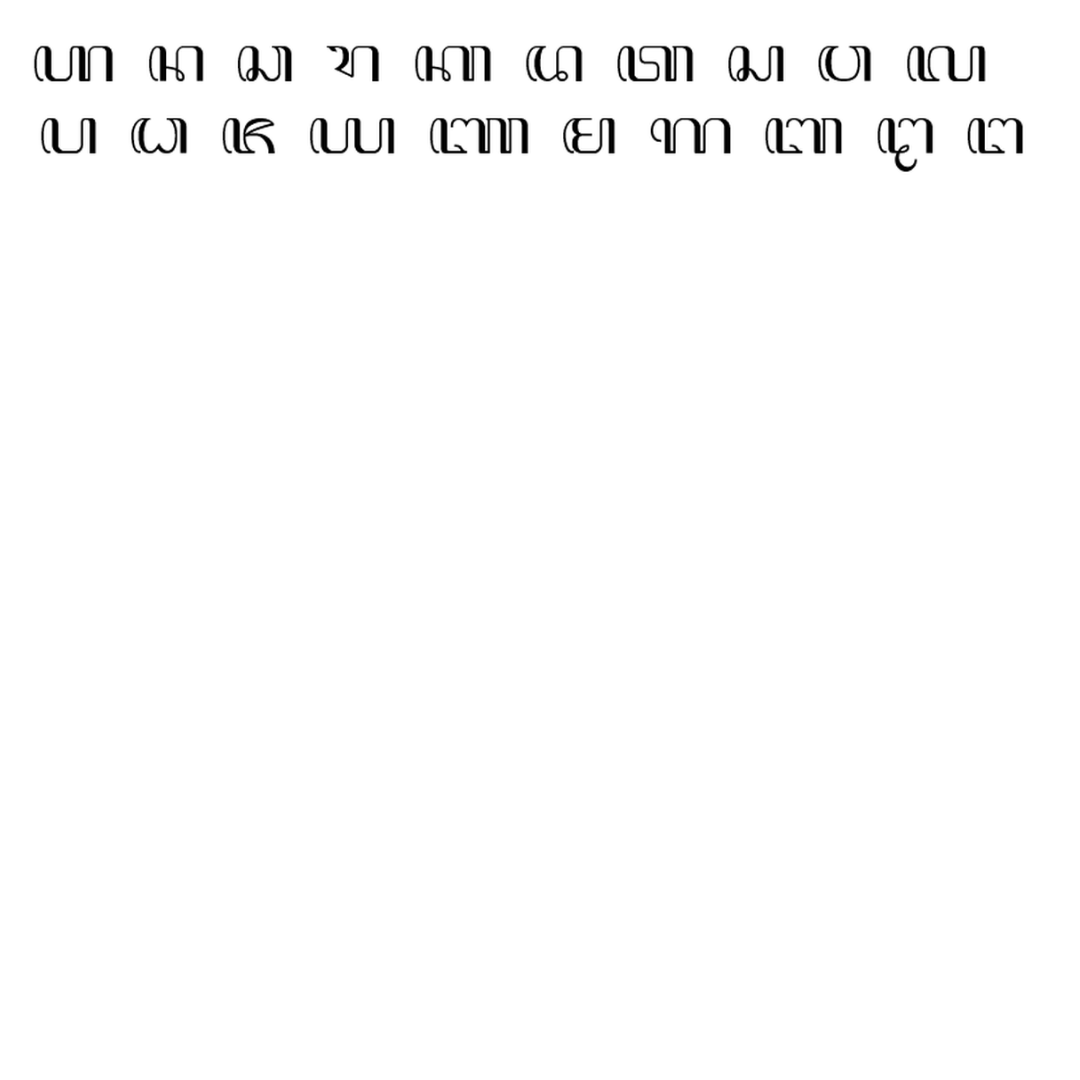

In [2]:
image_path = 'hanacaraka_edit.png'
image = cv2.imread(image_path)
cv2_imshow(image)

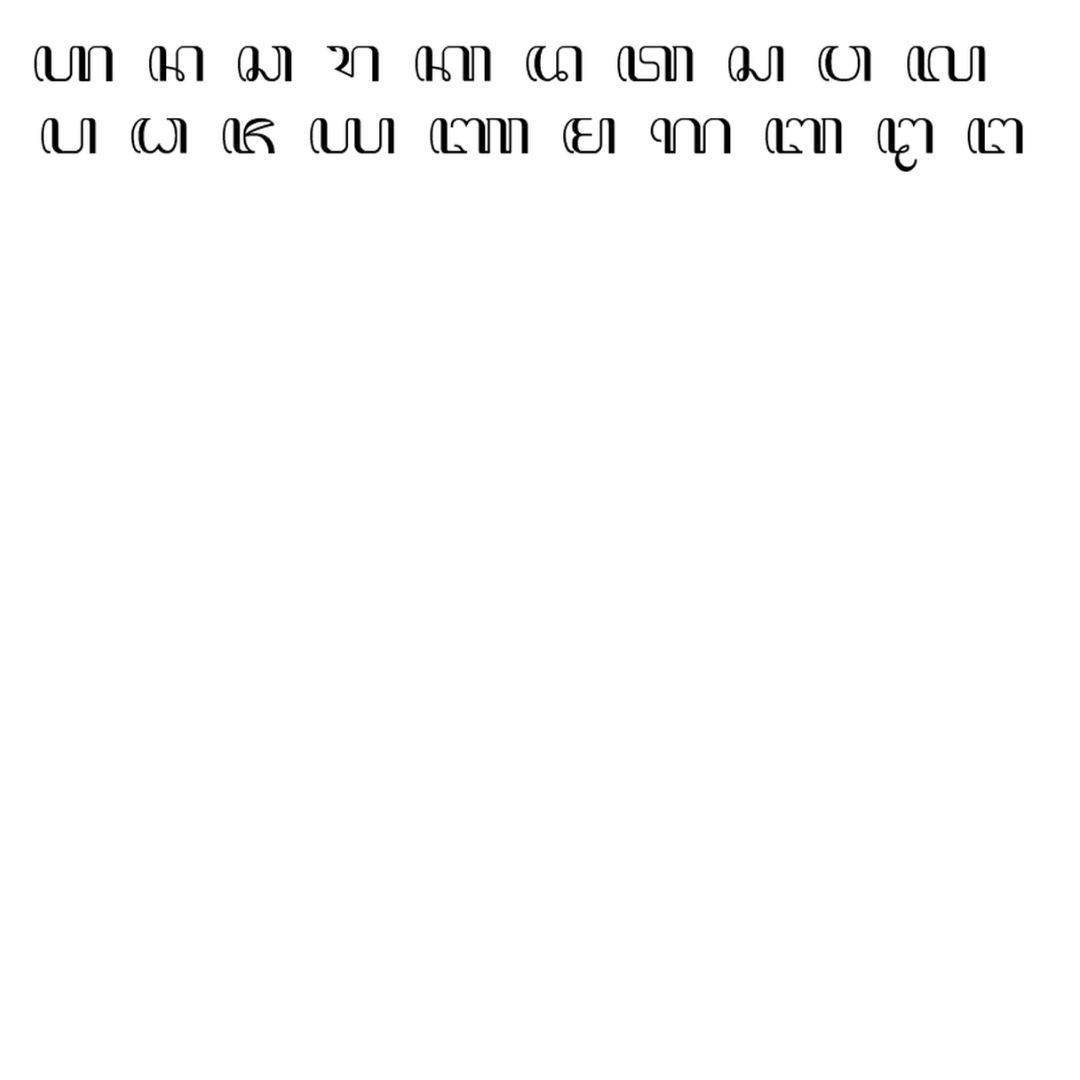

In [3]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

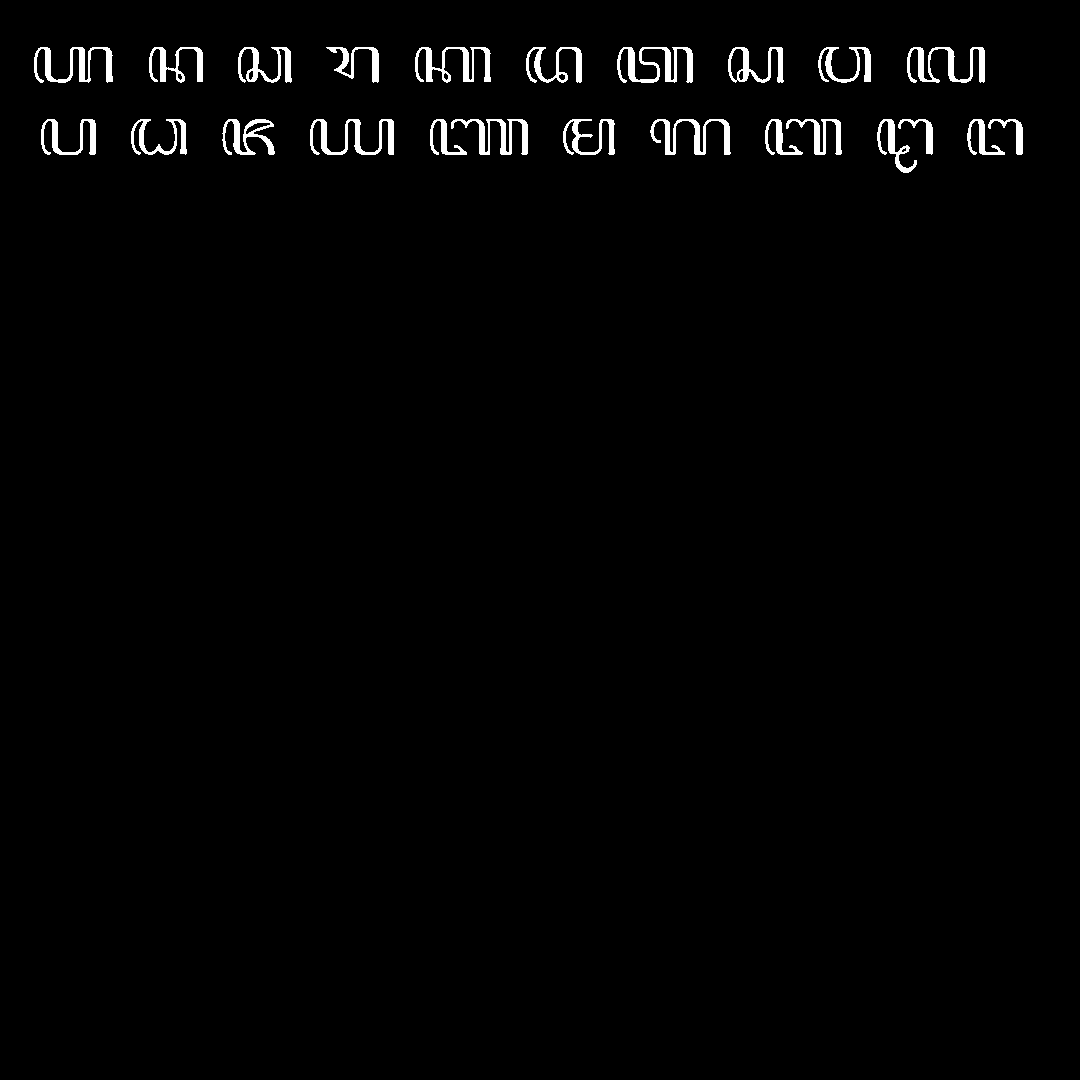

In [4]:
thresh = cv2.adaptiveThreshold(gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,21,10)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, (5,5))
cv2_imshow(thresh)

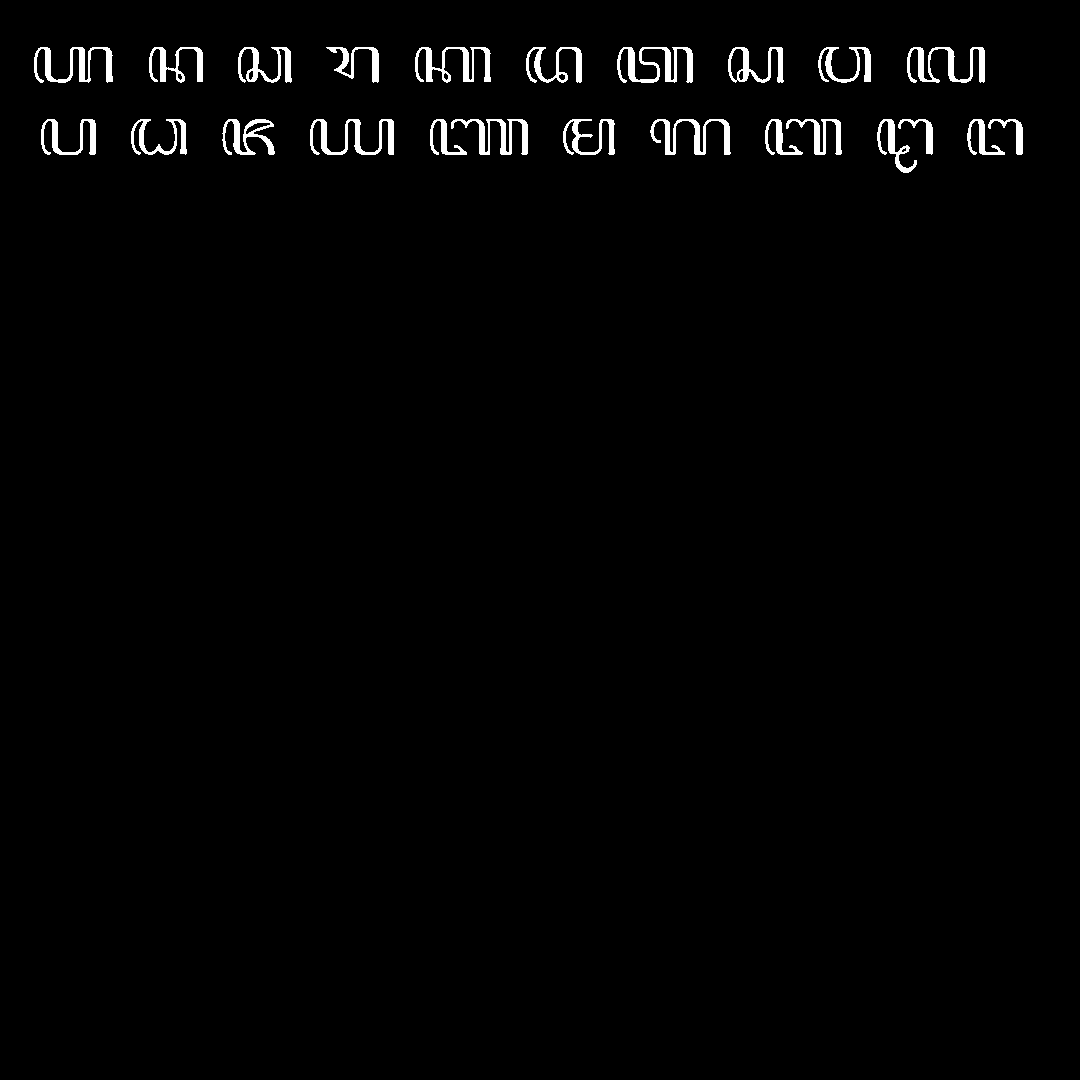

In [5]:
thresh = cv2.adaptiveThreshold(gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,21,10)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, (5,5))
cv2_imshow(thresh)

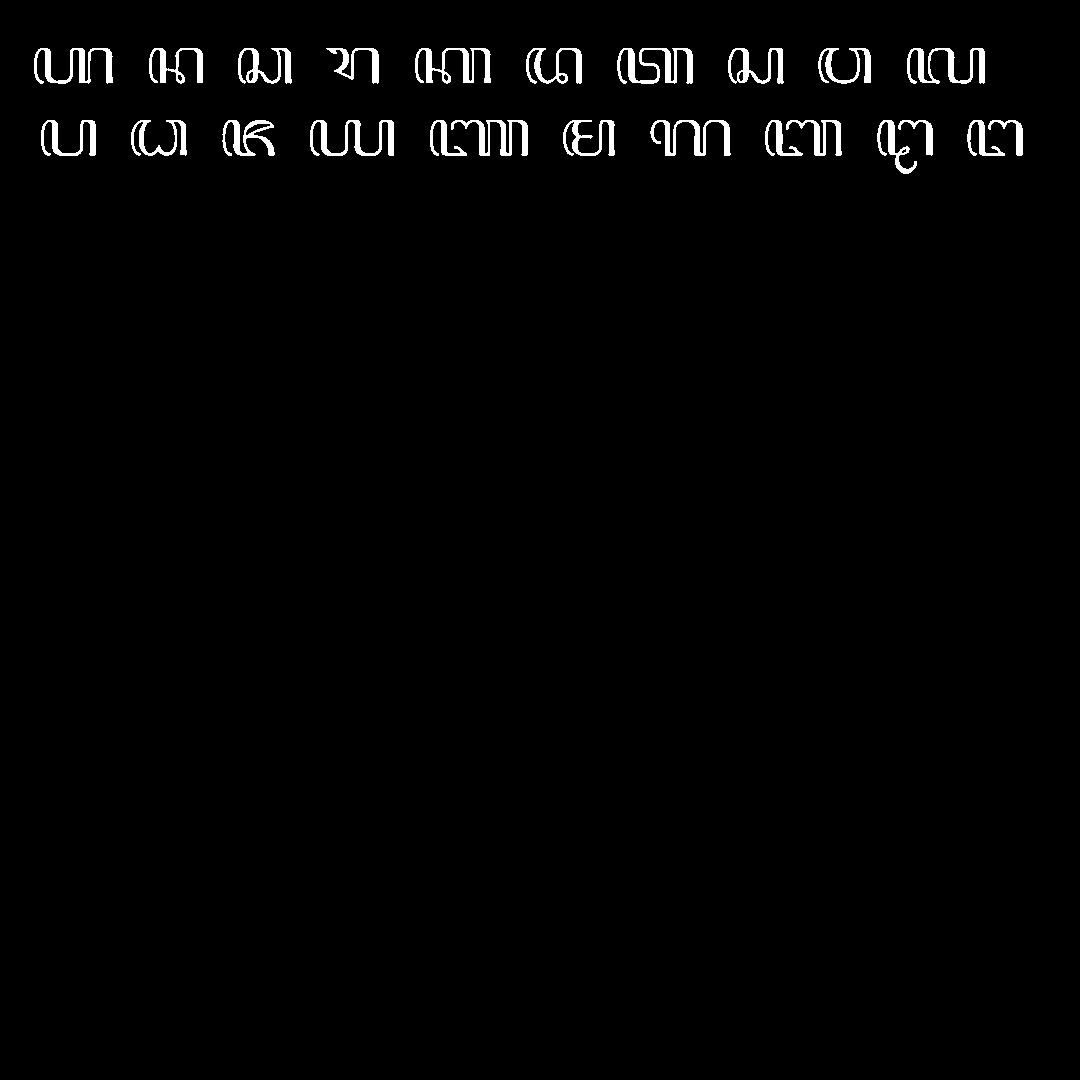

In [6]:
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, (5,5))
nb_components, output, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)
sizes = stats[1:, -1]; nb_components = nb_components - 1
min_size = 50
thresh = np.zeros((output.shape))
for i in range(0, nb_components):
  if sizes[i] >= min_size:
    thresh[output == i + 1] = 255
thresh = cv2.convertScaleAbs(thresh)
cv2_imshow(thresh)

34 48 79 36
41 120 55 36
131 120 56 36
149 48 54 36
222 120 53 36
238 48 54 36
310 120 84 36
326 48 53 36
415 48 76 36
430 120 37 36
451 120 77 36
526 48 56 36
563 120 52 36
617 48 76 36
650 120 81 36
728 48 56 36
765 120 38 36
786 120 56 36
818 48 53 36
877 120 40 54
898 120 35 36
907 48 78 36
967 120 38 36
988 120 35 36


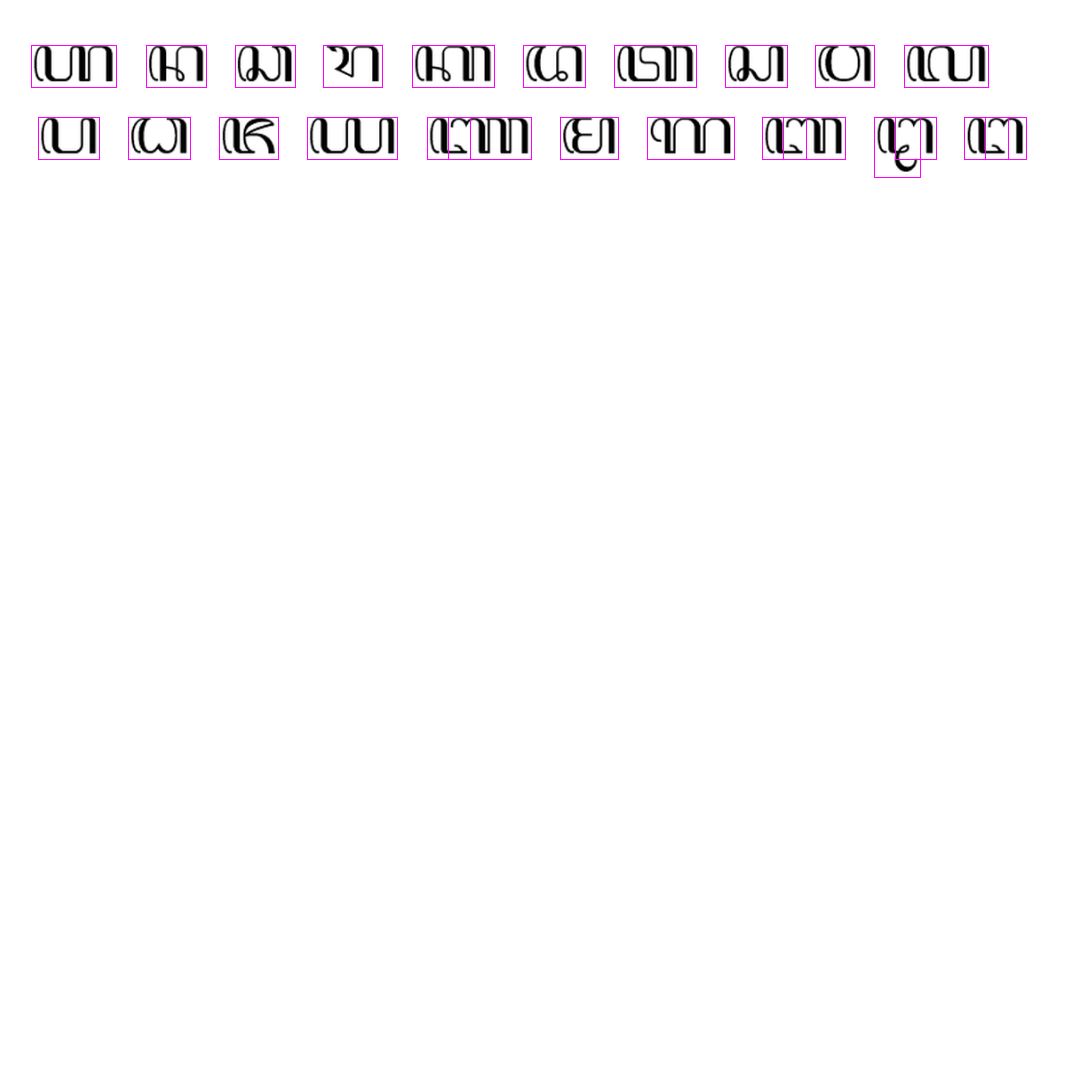

In [7]:
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
#sort contours
sorted_ctrs = sorted(ctrs, key=lambda ctr:cv2.boundingRect(ctr)[0])
for i, ctr in enumerate(sorted_ctrs):
  x, y, w, h = cv2.boundingRect(ctr)
  print(x,y,w,h)
  roi1 = thresh[y-3:y+h+3, x-3:x+w+3]
  cv2.rectangle(image,(x-3,y-3),( x + w + 3, y + h + 3),(255,0,255),1)
cv2_imshow(image)


In [8]:
import os
import shutil

# Directory path
directory = 'Predict/'

# Check if the directory exists
if os.path.exists(directory):
    # Clear all contents of the directory
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)  # Remove file or link
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)  # Remove directory and its contents
        except Exception as e:
            print(f'Failed to delete {file_path}. Reason: {e}')
else:
    # If the directory doesn't exist, create it
    os.makedirs(directory)
    print(f"Created directory: {directory}")

In [9]:
import cv2

# Assuming 'thresh' is your binary image
# Find contours
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours by Y-coordinate, and by X-coordinate if Y is the same
sorted_ctrs = sorted(ctrs, key=lambda ctr: (cv2.boundingRect(ctr)[1], cv2.boundingRect(ctr)[0]))

# Loop through sorted contours
for i, ctr in enumerate(sorted_ctrs):
    # Get bounding box
    x, y, w, h = cv2.boundingRect(ctr)

    # Getting ROI
    roi = thresh[y-3:y+h+3, x-3:x+w+3]

    # Inverting the ROI
    roi = cv2.bitwise_not(roi)

    # Resize ROI to 150x150
    roi = cv2.resize(roi, (150, 150))

    # Saving ROI as an image with bounding box coordinates in the filename
    path = 'Predict/'
    filename = f"{i}.jpg"  # Including x, y, w, h in the filename
    cv2.imwrite(path + filename, roi)
    print(path + filename)


Predict/0.jpg
Predict/1.jpg
Predict/2.jpg
Predict/3.jpg
Predict/4.jpg
Predict/5.jpg
Predict/6.jpg
Predict/7.jpg
Predict/8.jpg
Predict/9.jpg
Predict/10.jpg
Predict/11.jpg
Predict/12.jpg
Predict/13.jpg
Predict/14.jpg
Predict/15.jpg
Predict/16.jpg
Predict/17.jpg
Predict/18.jpg
Predict/19.jpg
Predict/20.jpg
Predict/21.jpg
Predict/22.jpg
Predict/23.jpg


In [23]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

def load_and_prepare_image(file_path, img_width, img_height):
    img = image.load_img(file_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array


def improve_image_quality(image_path):
    # Read the image
    img = cv2.imread(image_path)

    # Sharpen the image
    kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    sharpened = cv2.filter2D(img, -1, kernel)

    # Reduce noise
    denoised = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

    return sharpened, denoised

model = load_model('modelC.h5')  # Ganti dengan path ke model .h5 Anda



In [19]:
def load_and_prepare_image(file_path, img_width, img_height):
    # Load the image
    img = image.load_img(file_path, target_size=(img_width, img_height))

    # Convert the image to a numpy array
    img_array = image.img_to_array(img)

    # Apply sharpening
    kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])  # Sharpening kernel
    sharpened = cv2.filter2D(img_array, -1, kernel)

    # Enhance contrast using histogram equalization (applied only to the luminance channel)
    img_gray = cv2.cvtColor(sharpened.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    img_eq = cv2.equalizeHist(img_gray)
    sharpened[..., 0] = img_eq  # Apply equalized histogram to the first channel (luminance)

    # Apply noise reduction (optional)
    denoised = cv2.fastNlMeansDenoisingColored(np.uint8(sharpened), None, 10, 10, 7, 21)

    # Convert back to RGB (if necessary) after processing
    enhanced_img = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)

    # Add batch dimension
    img_array = np.expand_dims(enhanced_img, axis=0)

    return img_array

In [24]:
# Class names (based on your provided dataset)
train_dataset = [
    'ba', 'ca', 'da', 'dha', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na',
    'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'tha', 'wa', 'ya'
]

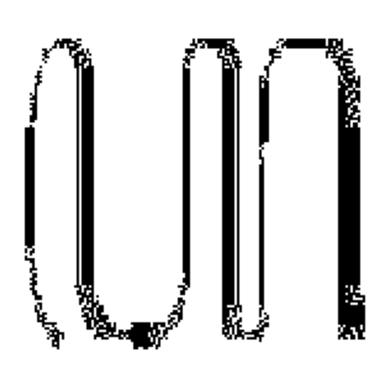

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step


[5]
File: 0.jpg -> Prediksi huruf Aksara Jawa: ha


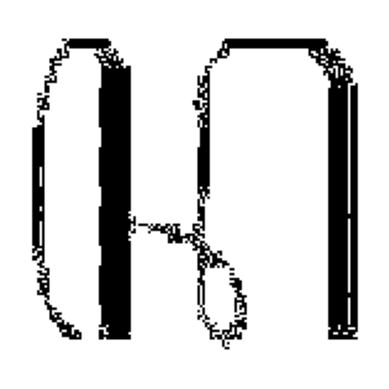

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


[13]
File: 1.jpg -> Prediksi huruf Aksara Jawa: pa


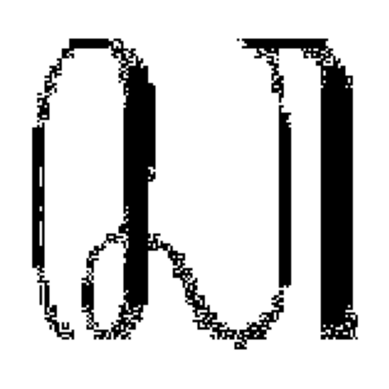

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


[11]
File: 2.jpg -> Prediksi huruf Aksara Jawa: nga


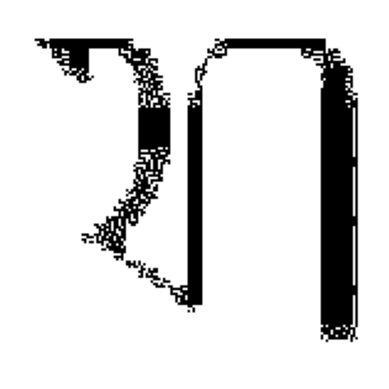

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


[4]
File: 3.jpg -> Prediksi huruf Aksara Jawa: ga


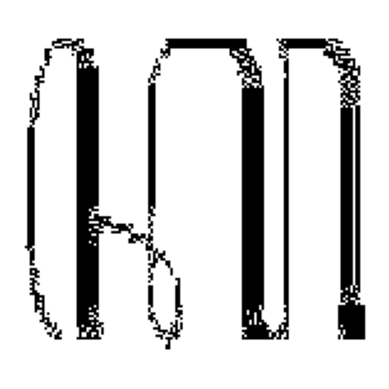

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


[12]
File: 4.jpg -> Prediksi huruf Aksara Jawa: nya


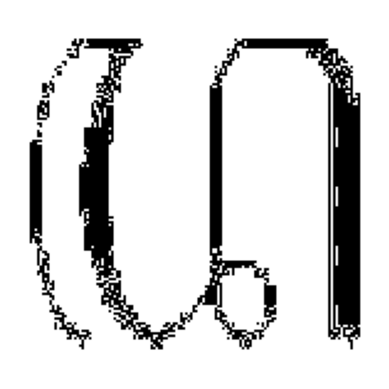

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


[13]
File: 5.jpg -> Prediksi huruf Aksara Jawa: pa


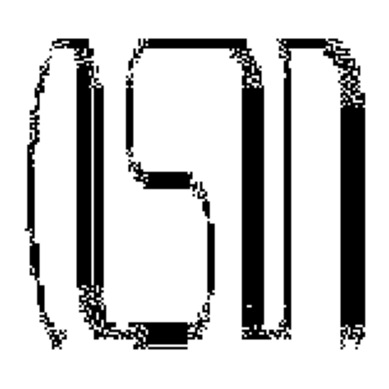

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[12]
File: 6.jpg -> Prediksi huruf Aksara Jawa: nya


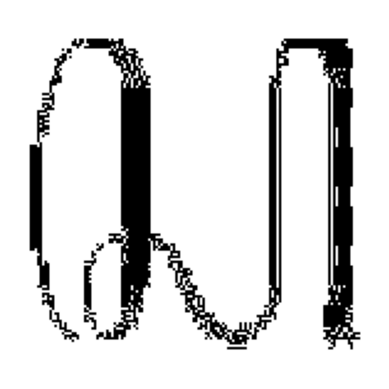

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


[11]
File: 7.jpg -> Prediksi huruf Aksara Jawa: nga


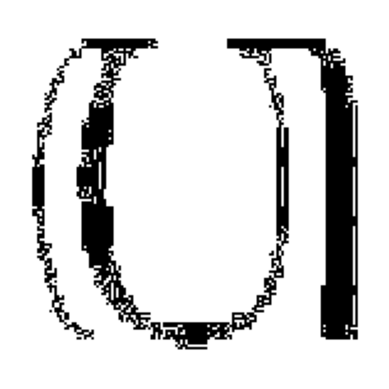

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


[18]
File: 8.jpg -> Prediksi huruf Aksara Jawa: wa


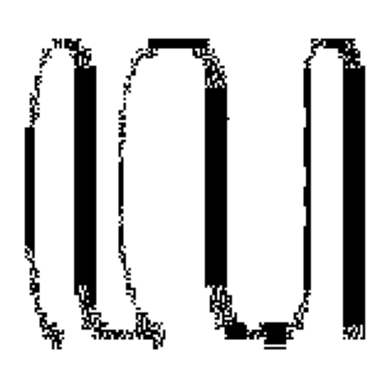

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


[13]
File: 9.jpg -> Prediksi huruf Aksara Jawa: pa


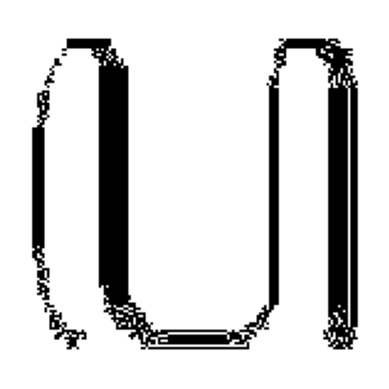

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[13]
File: 10.jpg -> Prediksi huruf Aksara Jawa: pa


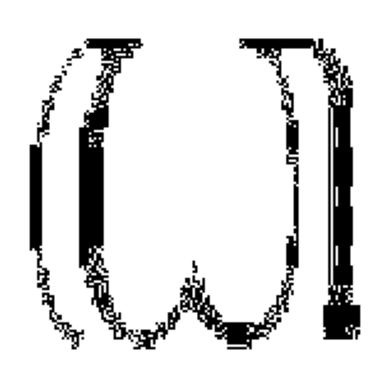

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


[17]
File: 11.jpg -> Prediksi huruf Aksara Jawa: tha


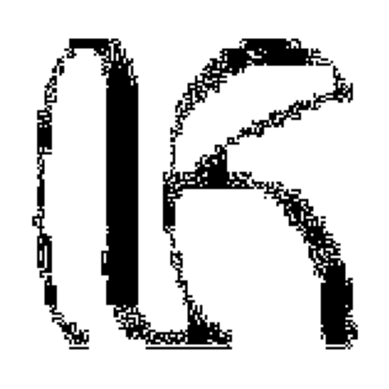

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


[6]
File: 12.jpg -> Prediksi huruf Aksara Jawa: ja


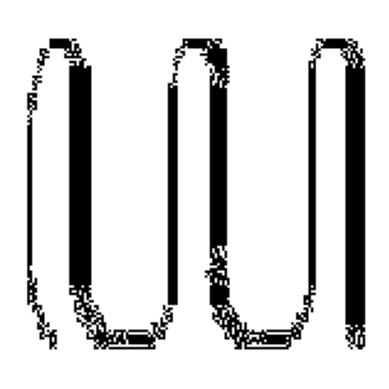

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


[13]
File: 13.jpg -> Prediksi huruf Aksara Jawa: pa


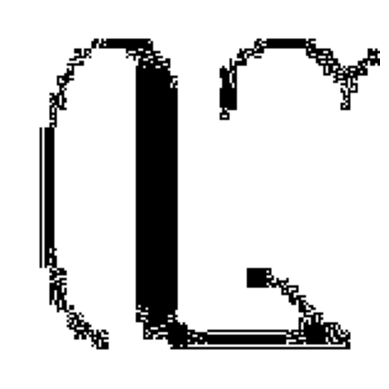

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


[8]
File: 14.jpg -> Prediksi huruf Aksara Jawa: la


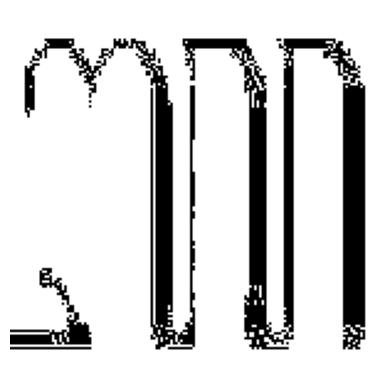

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


[4]
File: 15.jpg -> Prediksi huruf Aksara Jawa: ga


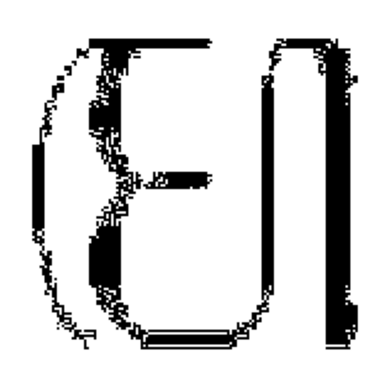

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


[11]
File: 16.jpg -> Prediksi huruf Aksara Jawa: nga


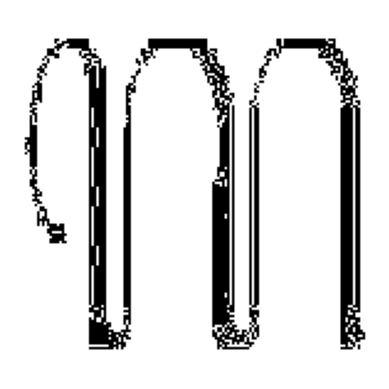

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


[5]
File: 17.jpg -> Prediksi huruf Aksara Jawa: ha


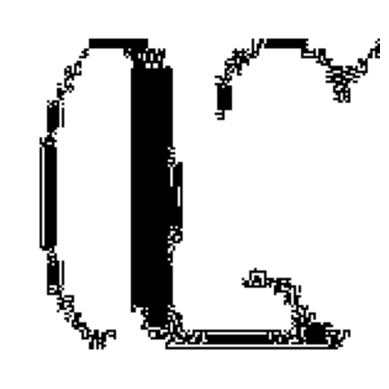

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


[8]
File: 18.jpg -> Prediksi huruf Aksara Jawa: la


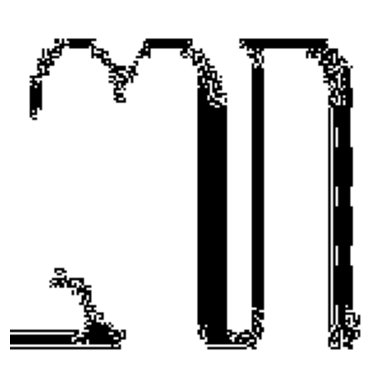

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


[5]
File: 19.jpg -> Prediksi huruf Aksara Jawa: ha


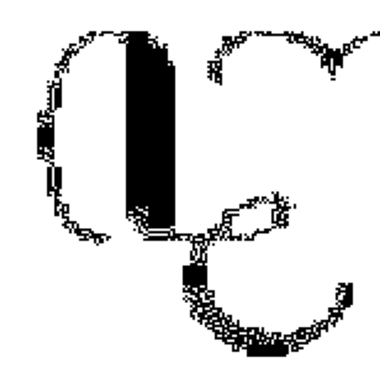

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


[2]
File: 20.jpg -> Prediksi huruf Aksara Jawa: da


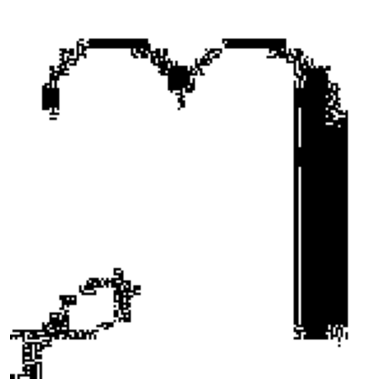

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


[11]
File: 21.jpg -> Prediksi huruf Aksara Jawa: nga


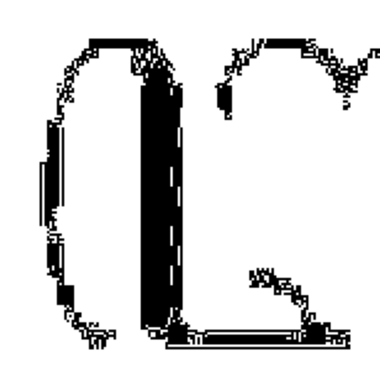

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


[8]
File: 22.jpg -> Prediksi huruf Aksara Jawa: la


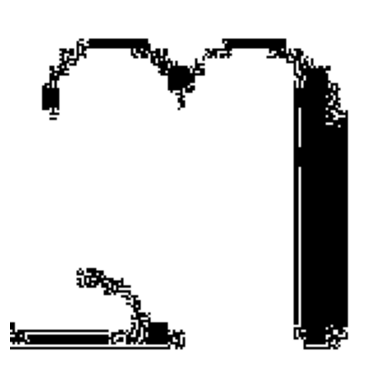

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[11]
File: 23.jpg -> Prediksi huruf Aksara Jawa: nga


In [25]:
import re
import matplotlib.pyplot as plt
import os

# Folder containing the images you want to predict
folder_path = 'Predict'  # Replace with your folder path

# Image dimensions (should match the model's input size)
img_width, img_height = 150, 150
image_files = sorted(
    [f for f in os.listdir(folder_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))],
    key=lambda f: int(re.search(r'(\d+)', f).group(0))  # Extract the first number from the filename
)
# Loop through all files in the folder and predict the class for each image
for filename in image_files:
    file_path = os.path.join(folder_path, filename)

    # Check if the file is an image (optional, you can adjust the condition as needed)
    if file_path.lower().endswith(('jpg', 'jpeg', 'png')):
        # Load and preprocess the image
        img_array = load_and_prepare_image(file_path, img_width, img_height)
        plt.imshow(img_array[0])
        plt.axis('off')  # Hide the axis
        plt.show()

        # Predict the class of the image
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)
        print(predicted_class_index)

        # Get the predicted class name
        predicted_class_name = train_dataset[predicted_class_index[0]]

        # Print the prediction result
        print(f"File: {filename} -> Prediksi huruf Aksara Jawa: {predicted_class_name}")


(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
(1, 150, 150, 3)
Input shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
(1, 150, 150, 3)
Input shape: (

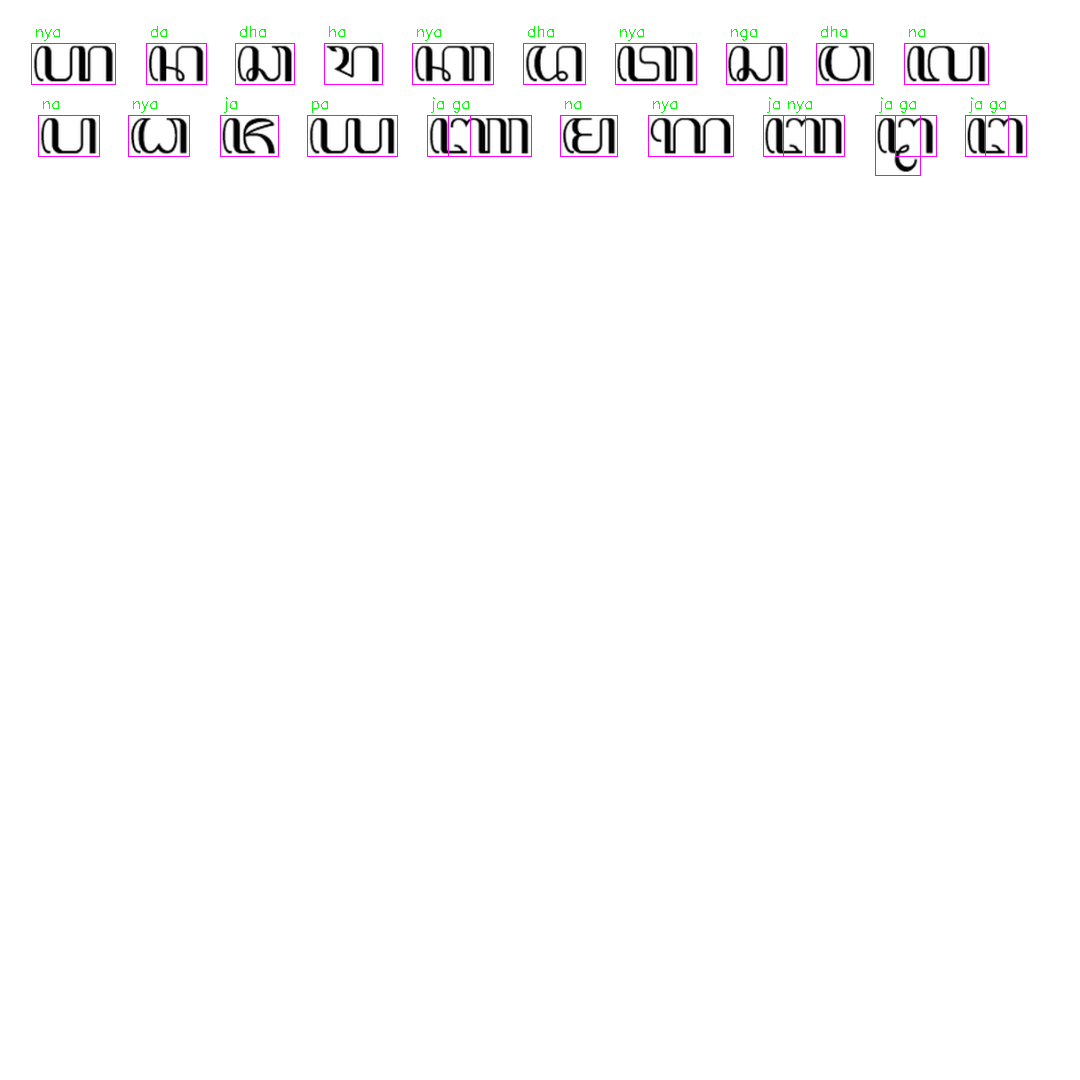

In [30]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Configuration
MODEL_PATH = "modelC.h5"  # Replace with your model's path
IMG_WIDTH, IMG_HEIGHT = 150, 150     # Dimensions expected by the model
aksara_classes = [
    'ba', 'ca', 'da', 'dha', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na',
    'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'tha', 'wa', 'ya'
]
# Load the trained model
model = load_model(MODEL_PATH)


def preprocess_roi(roi, img_width, img_height, channels=1):
    """
    Preprocess an ROI for model prediction.

    Parameters:
    - roi: The input region of interest (image array).
    - img_width: Target width for resizing (model input width).
    - img_height: Target height for resizing (model input height).
    - channels: Number of channels expected by the model (default: 1 for grayscale).

    Returns:
    - Preprocessed ROI ready for prediction.
    """
    # Resize the ROI to the model's input dimensions
    roi = cv2.resize(roi, (img_width, img_height))

    # If the model expects RGB (3 channels), convert the ROI to 3 channels
    if channels == 3:
        roi = cv2.cvtColor(roi, cv2.COLOR_GRAY2RGB)

    # Normalize pixel values to the range [0, 1]
    # Expand dimensions to match the batch and channel format expected by the model
    roi = np.expand_dims(roi, axis=0)  # Add batch dimension (1, img_width, img_height, channels)

    return roi

def preprocess_roi(roi, img_width, img_height, channels=1, sharpen=True, denoise=True):
    """
    Preprocess an ROI for model prediction, including optional image enhancement.

    Parameters:
    - roi: The input region of interest (image array).
    - img_width: Target width for resizing (model input width).
    - img_height: Target height for resizing (model input height).
    - channels: Number of channels expected by the model (default: 1 for grayscale).
    - sharpen: Whether to apply sharpening (default: True).
    - denoise: Whether to apply denoising (default: True).

    Returns:
    - Preprocessed ROI ready for prediction.
    """
    # Optional: Apply sharpening
    if sharpen:
        kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
        roi = cv2.filter2D(roi, -1, kernel)


    # Resize the ROI to the model's input dimensions
    roi = cv2.resize(roi, (img_width, img_height))

    # If the model expects RGB (3 channels), convert the ROI to 3 channels
    if channels == 3:
        roi = cv2.cvtColor(roi, cv2.COLOR_GRAY2RGB)

    # Normalize pixel values to the range [0, 1]
    # Expand dimensions to match the batch and channel format expected by the model
    roi = np.expand_dims(roi, axis=0)  # Add batch dimension (1, img_width, img_height, channels)

    return roi

# Read the input image in grayscale
input_image_path = "hanacaraka_edit.png"  # Replace with your image path
image = cv2.imread(input_image_path)
if image is None:
    raise ValueError(f"Image not found: {input_image_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# Find contours
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours from left to right
sorted_ctrs = sorted(ctrs, key=lambda ctr: cv2.boundingRect(ctr)[0])

# Loop through sorted contours
for i, ctr in enumerate(sorted_ctrs):
    # Get bounding box
    x, y, w, h = cv2.boundingRect(ctr)

    # Extract ROI with padding
    roi = thresh[max(0, y-3):y+h+3, max(0, x-3):x+w+3]

    # Preprocess the ROI for prediction
    roi_preprocessed = preprocess_roi(roi, img_width=150, img_height=150, channels=3)
    print(roi_preprocessed.shape)
    print("Input shape:", model.input_shape)



    # Predict the class
    prediction = model.predict(roi_preprocessed)
    predicted_class_index = np.argmax(prediction, axis=1)[0]
    predicted_class_name = aksara_classes[predicted_class_index]

    # Draw bounding box and add the predicted class name
    cv2.rectangle(image, (x-3, y-3), (x + w + 3, y + h + 3), (255, 0, 255), 1)
    cv2.putText(image, predicted_class_name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# Display the final image using cv2.imshow
cv2_imshow(image)  # Show the image in a window titled 'Final Image'
cv2.waitKey(0)  # Wait for a key press to close the window
cv2.destroyAllWindows()  # Close all OpenCV windows


(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
(1, 150, 150)
Input shape: (None, 150, 150, 1)
1/1 ━━━━━━━━━━━━━

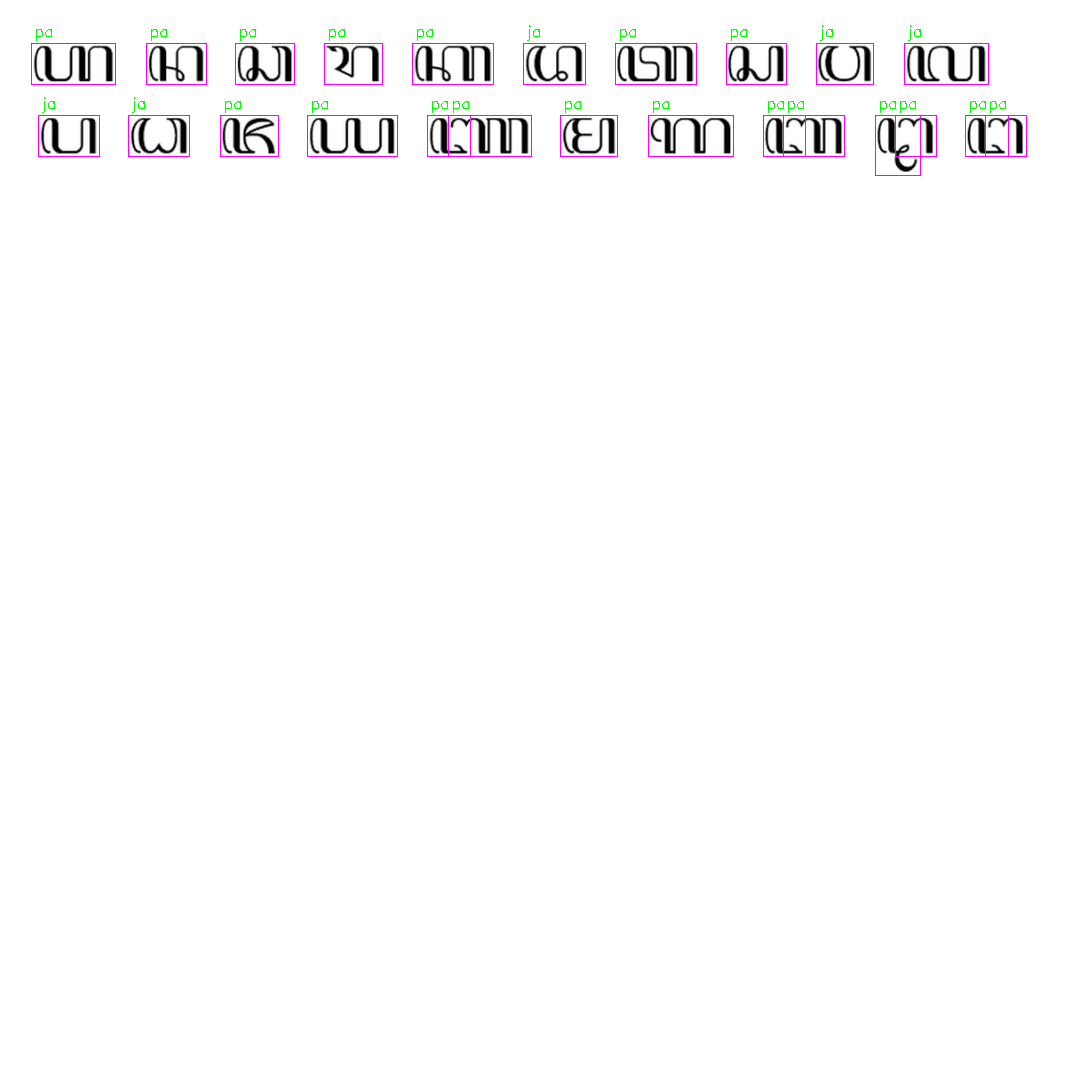

In [15]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Configuration
MODEL_PATH = "modelB.h5"  # Replace with your model's path
IMG_WIDTH, IMG_HEIGHT = 150, 150     # Dimensions expected by the model
aksara_classes = [
    'ba', 'ca', 'da', 'dha', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na',
    'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'tha', 'wa', 'ya'
]
# Load the trained model
model = load_model(MODEL_PATH)

def preprocess_roi(roi, img_width, img_height, channels=1):
    """
    Preprocess the Region of Interest (ROI) for prediction.

    Args:
        roi: The input image (Region of Interest) as a numpy array.
        img_width: The width to resize the image.
        img_height: The height to resize the image.
        channels: Number of channels for the model input (default: 1 for grayscale).

    Returns:
        Preprocessed image ready for model prediction.
    """
    roi = cv2.resize(roi, (img_width, img_height))  # Resize to model input size
    roi = roi.astype('float32') / 255.0             # Normalize pixel values to [0, 1]
    if channels == 1:
        roi = np.expand_dims(roi, axis=-1)          # Add channel dimension for grayscale
    roi = np.expand_dims(roi, axis=0)               # Add batch dimension
    return roi


# Read the input image in grayscale
input_image_path = "hanacaraka_edit.png"  # Replace with your image path
image = cv2.imread(input_image_path)
if image is None:
    raise ValueError(f"Image not found: {input_image_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# Find contours
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours from left to right
sorted_ctrs = sorted(ctrs, key=lambda ctr: cv2.boundingRect(ctr)[0])

# Loop through sorted contours
for i, ctr in enumerate(sorted_ctrs):
    # Get bounding box
    x, y, w, h = cv2.boundingRect(ctr)

    # Extract ROI with padding
    roi = thresh[max(0, y-3):y+h+3, max(0, x-3):x+w+3]

    # Preprocess the ROI for prediction
    roi_preprocessed = preprocess_roi(roi, img_width=150, img_height=150, channels=3)
    print(roi_preprocessed.shape)
    print("Input shape:", model.input_shape)



    # Predict the class
    prediction = model.predict(roi_preprocessed)
    predicted_class_index = np.argmax(prediction, axis=1)[0]
    predicted_class_name = aksara_classes[predicted_class_index]

    # Draw bounding box and add the predicted class name
    cv2.rectangle(image, (x-3, y-3), (x + w + 3, y + h + 3), (255, 0, 255), 1)
    cv2.putText(image, predicted_class_name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# Display the final image using cv2.imshow
cv2_imshow(image)  # Show the image in a window titled 'Final Image'
cv2.waitKey(0)  # Wait for a key press to close the window
cv2.destroyAllWindows()  # Close all OpenCV windows


In [16]:

# Fungsi untuk memuat dan mempersiapkan gambar
def load_and_prepare_image(image, img_width, img_height):
    image_resize = cv2.resize(image, (img_width, img_height))
    print(image_resize)
    image_array = np.array(image_resize)
    print(image_array)
    img_array = np.expand_dims(image, axis=0)  # Membuat batch yang terdiri dari satu gambar
    return img_array

model = load_model('/content/modelC.h5')  # Ganti dengan path ke model .h5 Anda



In [17]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Example threshold image (replace with your actual thresholded image)
# 'image' is the original image.

# Find contours
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours by Y-coordinate, and by X-coordinate if Y is the same
sorted_ctrs = sorted(ctrs, key=lambda ctr: (cv2.boundingRect(ctr)[1], cv2.boundingRect(ctr)[0]))

for i, ctr in enumerate(sorted_ctrs):
    # Get bounding box
    x, y, w, h = cv2.boundingRect(ctr)
    # Extract region of interest (ROI)
    roi1 = thresh[y-3:y+h+3, x-3:x+w+3]


    # Preprocess the ROI image for prediction
    roi_img_array = load_and_prepare_image(roi1, 150, 150)

    # Predict the class for the ROI image
    predictions = model.predict(roi_img_array)
    predicted_class_index = np.argmax(predictions, axis=1)

    # Mendapatkan nama kelas dari class_names
    print(predictions)
    print(predicted_class_index)
    train_dataset = ['ba',
      'ca',
      'da',
      'dha',
      'ga',
      'ha',
      'ja',
      'ka',
      'la',
      'ma',
      'na',
      'nga',
      'nya',
      'pa',
      'ra',
      'sa',
      'ta',
      'tha',
      'wa',
      'ya']



    # Draw bounding box
    cv2.rectangle(image, (x-3, y-3), (x + w + 3, y + h + 3), (255, 0, 255), 1)

    # Add text for position (x, y, w, h)
    position_text = f"{predicted_class_name}"

    cv2.putText(image, position_text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# Display the image with annotations
cv2_imshow(image)


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("sequential_1/Cast:0", shape=(1, 41, 84), dtype=float32). Expected shape (None, 150, 150, 3), but input has incompatible shape (1, 41, 84)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 41, 84), dtype=uint8)
  • training=False
  • mask=None

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Fungsi untuk memuat dan mempersiapkan gambar
def load_and_prepare_image(file_path, img_width, img_height):
    img = image.load_img(file_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Membuat batch yang terdiri dari satu gambar
    # print img array_property
    print(img_array)
    return img_array

# Memprediksi gambar baru
file_path = '/content/test-nga1.png'  # Ganti dengan path ke gambar yang ingin diprediksi
img_width, img_height = 150, 150  # Ganti dengan dimensi yang sesuai dengan model
img_array = load_and_prepare_image(file_path, img_width, img_height)

predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)

# Mendapatkan nama kelas dari class _names
train_dataset_class_names = ['ba',
      'ca',
      'da',
      'dha',
      'ga',
      'ha',
      'ja',
      'ka',
      'la',
      'ma',
      'na',
      'nga',
      'nya',
      'pa',
      'ra',
      'sa',
      'ta',
      'tha',
      'wa',
      'ya']

predicted_class_name = train_dataset_class_names[predicted_class_index[0]]

print(f"Prediksi huruf Aksara Jawa: {predicted_class_name}")

    # Mendapatkan nama kelas dari class_names



In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Ensure you have these defined before this code
# model = load_model('path_to_your_trained_model.h5')
# image = cv2.imread('your_image.jpg')
# thresh = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

def load_and_prepare_image(img, img_width, img_height):
    """
    Prepare an image (either file path or numpy array) for prediction

    Args:
    img: Image file path or numpy array
    img_width: Target width
    img_height: Target height

    Returns:
    Preprocessed image array ready for model prediction
    """
    # If input is a file path
    if isinstance(img, str):
        img = image.load_img(img, target_size=(img_width, img_height))
        img_array = image.img_to_array(img)
    # If input is a numpy array
    else:
        img_resized = cv2.resize(img, (img_width, img_height))
        img_array = img_resized

    img_array = np.expand_dims(img_array, axis=0)  # Create batch of one image
    return img_array

def detect_and_classify_objects(image, thresh, model, class_names):
    """
    Detect objects in thresholded image and classify them

    Args:
    image: Original image
    thresh: Thresholded image
    model: Trained classification model
    class_names: List of class names

    Returns:
    Image with bounding boxes and classifications
    """
    # Find contours
    ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Sort contours by Y-coordinate, then X-coordinate
    sorted_ctrs = sorted(ctrs, key=lambda ctr: (cv2.boundingRect(ctr)[1], cv2.boundingRect(ctr)[0]))

    for ctr in sorted_ctrs:
        # Get bounding box
        x, y, w, h = cv2.boundingRect(ctr)

        # Extract region of interest (ROI) with some padding
        roi1 = thresh[max(0, y-3):y+h+3, max(0, x-3):x+w+3]

        # Preprocess the ROI image for prediction
        roi_img_array = load_and_prepare_image(roi1, 150, 150)

        # Predict the class for the ROI image
        predictions = model.predict(roi_img_array)
        predicted_class_index = np.argmax(predictions, axis=1)

        # Get class name
        predicted_class_name = class_names[predicted_class_index[0]]

        # Draw bounding box
        cv2.rectangle(image, (x-3, y-3), (x + w + 3, y + h + 3), (255, 0, 255), 1)

        # Add text with class name
        cv2.putText(image, predicted_class_name, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    return image

# Example usage (you'll need to replace these with your actual data)
# image = cv2.imread('your_image.jpg')
# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
# model = load_model('your_model.h5')
# class_names = ['class1', 'class2', 'class3']  # Your actual class names

# result_image = detect_and_classify_objects(image, thresh, model, class_names)
# cv2.imshow('Detected Objects', result_image)
# cv2.waitKey(0)

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow

# Fungsi untuk memuat dan mempersiapkan gambar
def load_and_prepare_image(file_path, img_width, img_height):
    img = image.load_img(file_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Membuat batch yang terdiri dari satu gambar
    return img_array

# Load the model from the .h5 file
model = load_model('/content/modelC.h5')  # Ganti dengan path ke model .h5 Anda

# Example threshold image (replace with your actual thresholded image)
image_path = 'Ha.jpg'  # Ganti dengan path ke gambar asli
image = cv2.imread(image_path)
thresh = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Ganti dengan thresholding yang sesuai

# Find contours
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours by Y-coordinate, and by X-coordinate if Y is the same
sorted_ctrs = sorted(ctrs, key=lambda ctr: (cv2.boundingRect(ctr)[1], cv2.boundingRect(ctr)[0]))

for i, ctr in enumerate(sorted_ctrs):
    # Get bounding box
    x, y, w, h = cv2.boundingRect(ctr)

    # Extract region of interest (ROI)
    roi = thresh[y-3:y+h+3, x-3:x+w+3]

    # Preprocess the ROI image for prediction
    roi_img_array = load_and_prepare_image(roi, 150, 150)

    # Predict the class for the ROI image
    predictions = model.predict(roi_img_array)
    predicted_class_index = np.argmax(predictions, axis=1)

    # Mendapatkan nama kelas dari class_names
    predicted_class_name = model.class_names[predicted_class_index[0]]

    # Draw bounding box
    cv2.rectangle(image, (x-3, y-3), (x + w + 3, y + h + 3), (255, 0, 255), 1)

    # Add text for position and predicted class (x, y, w, h, predicted class)
    position_text = f"({x},{y},{w},{h}) - {predicted_class_name}"
    cv2.putText(image, position_text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# Display the image with annotations
cv2_imshow(image)
